# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

## Provisional lane: Lane 2 — Refresh / Content Opportunity Scoring.

I'm picking this lane because it produces a ranked list a real reviewer can act on today, and the starter data already shows a large, workable pool of candidate pages (see the numbers in Section 3). It also matches the strongest-supported workflow in the repo: a transparent baseline score to beat, then a model, then a ranked queue with reason codes. I can confirm or swap this by Week 4 once I've looked at the warehouse release.

In [8]:
# No computation needed for this section — reasoning lives in the markdown above.
print('Lane: Refresh / Content Opportunity Scoring')

Lane: Refresh / Content Opportunity Scoring


## 2. The question: decision, action, cost of a wrong call

### *What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

**Search question:** Which content pages should a content reviewer look at first, out of everything a client owns, given limited review capacity?

**Unit of analysis:** One content page (`content_id`), described by its trailing-90-day search and engagement signals.

**Output:** A ranked queue of pages, each with a score, a suggested action (refresh, protect, prune, or monitor), and a reason code the reviewer can inspect.

**Decision it improves:** On which pages a content team spends its limited weekly review hours on.

**Who acts:** A content strategist or SEO editor with a fixed review budget (say, 20-50 pages a week).

**Cost of a wrong call:**
- *False positive* (flagged as urgent, isn't really): Wastes a reviewer's time on a page that didn't need it — a real but small cost.
- *False negative* (a genuinely declining, high-value page never surfaces): The page keeps losing visibility unnoticed — a larger, compounding cost, since traffic lost to a competitor is harder to win back later.
Because missing a real decline is costlier than a wasted review, the ranking should lean toward catching true positives, not just being cautious.

**Why data or ML helps:** With 30,000+ pages per client base and 44 signals each, no reviewer can manually rank them by hand, and a single hard-coded if-statement (the baseline) treats every signal as equally important. A model can weigh multiple signals together and rank pages the baseline rule misses — Section 3 shows the baseline vs. model gap is real, not assumed.

In [9]:
# No computation needed for this section — framing lives in the markdown above.

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [10]:
import pandas as pd

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')

# Same eligibility filter the starter pipeline uses: has demand, old enough to judge
elig = df[(df['impressions_90d'] > 0) & (df['content_age_days'] >= 90)].drop_duplicates('content_id')

print('Eligible pages:', len(elig), 'across', elig['client_id'].nunique(), 'clients')

declining_with_demand = elig[(elig['trend_direction'] == 'down') & (elig['impressions_90d'] >= 100)]
print('declining_with_demand candidates:', len(declining_with_demand),
      f"({len(declining_with_demand)/len(elig)*100:.1f}% of eligible pages)")

low_ctr = elig[(elig['impressions_90d'] >= 500) & (elig['avg_position'] > 0) &
               (elig['avg_position'] <= 20) & (elig['ctr'] < 0.5)]
print('low_ctr_visible_page candidates:', len(low_ctr),
      f"({len(low_ctr)/len(elig)*100:.1f}% of eligible pages)")

print('Median impressions_90d among eligible pages:', elig['impressions_90d'].median())

Eligible pages: 30000 across 32 clients
declining_with_demand candidates: 13152 (43.8% of eligible pages)
low_ctr_visible_page candidates: 9759 (32.5% of eligible pages)
Median impressions_90d among eligible pages: 731.0


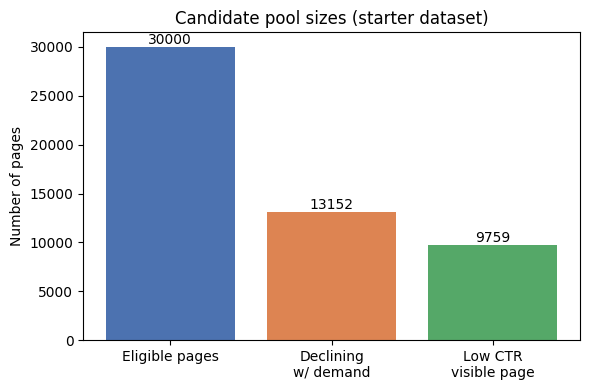

In [11]:
import matplotlib.pyplot as plt

labels = ['Eligible pages', 'Declining\nw/ demand', 'Low CTR\nvisible page']
values = [len(elig), len(declining_with_demand), len(low_ctr)]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Candidate pool sizes (starter dataset)')
plt.ylabel('Number of pages')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 300, str(v), ha='center')
plt.tight_layout()
plt.show()

### **What these numbers say:**
Out of 30,000 starter rows, 32 clients have pages eligible for review. Roughly 44% of those already match a plain "declining with real demand" rule, and about a third match a "visible but low click-through" rule — two different, sizeable candidate pools, not a handful of edge cases. With a typical page pulling a median of ~730 impressions in 90 days, most candidates carry real search demand, not noise. That's enough signal volume to justify building past a simple rule and testing whether a model ranks these pages better than the rule alone (the repo's own pipeline already shows a baseline-vs-model gap: precision@50 of 0.24 for the rule vs. 0.74 for a random forest, on this same starter slice).

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

### **What this work CAN say:**

**Observed:** The which pages show measurable decline, low CTR relative to their position tier, or staleness, based on the trailing-90-day window.

**Directional:** The which signals tend to move together with decline or opportunity, as evidence, not certainty.

**Decision-Support:** A ranked queue that helps a reviewer spend limited time on the most promising pages first.

### **What this work CANNOT say:**

**->** It cannot prove a refresh will cause a recovery — that needs a real experiment (e.g., before/after with a control group), not this data alone.

**->** It cannot claim to have found or reverse-engineered a Google ranking factor.

**->** It cannot claim AI search visibility or AI citations — only that a session came from an AI referral, not that content was "seen" by an AI system.

**->** It cannot treat the current-window is_declining_label as a real future outcome — it's a proxy computed from the same window, not a forecast, until I build a proper prior-window-to-future-window label.

In [12]:
# No computation needed for this section — framing lives in the markdown above.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] **My claims use careful words:** observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.